🚀 CUSTOMER RETENTION ENGINE - RFM ANALYSIS

✅ Datasets loaded successfully!
   📊 Orders: 99,441 rows
   📊 Order Items: 112,650 rows
   📊 Customers: 99,441 rows
   📊 Payments: 103,886 rows

📋 STEP 2: DATA EXPLORATION

--- Orders Dataset Preview ---
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2         

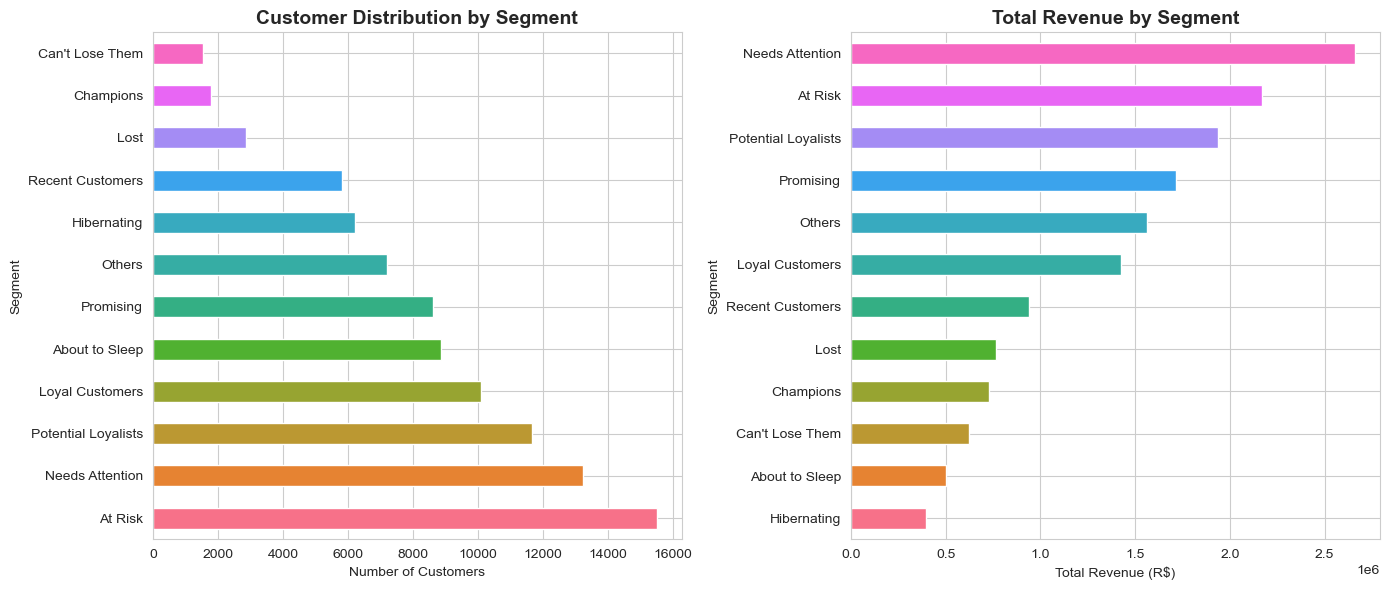

✅ Saved: rfm_distributions.png


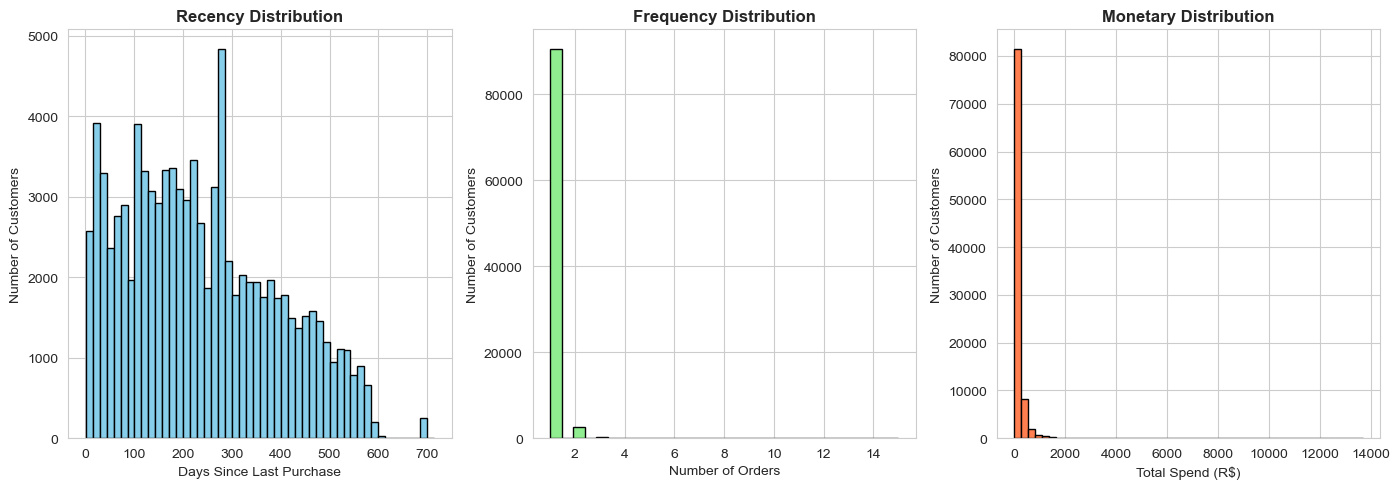

✅ Saved: segment_heatmap.png


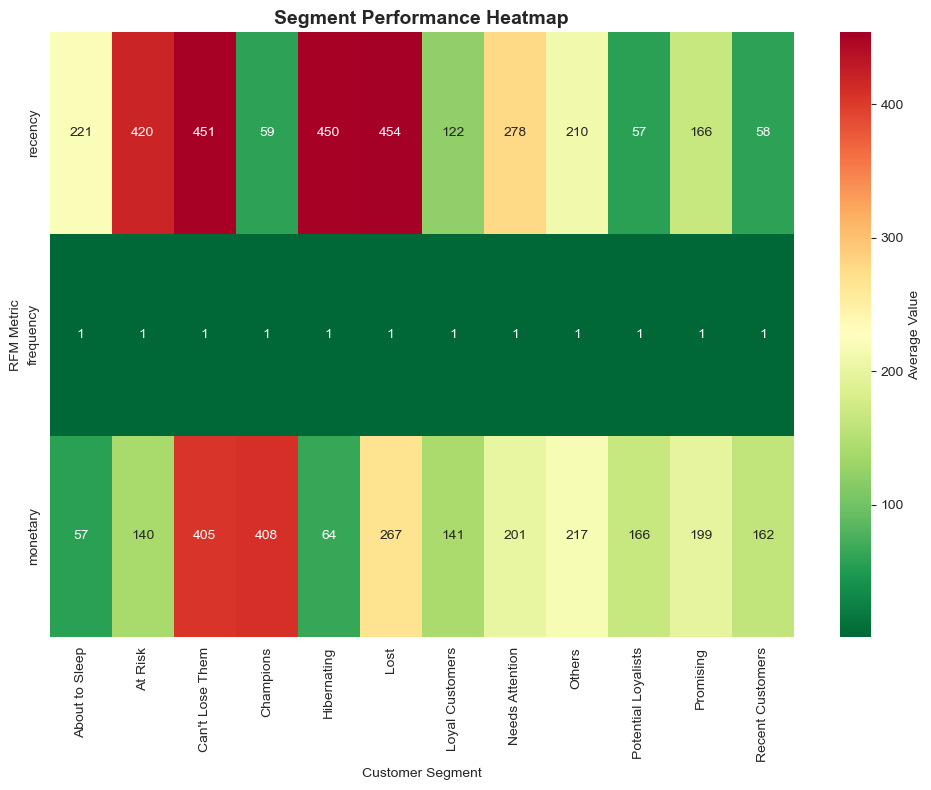

✅ Saved: top_segments_ltv.png


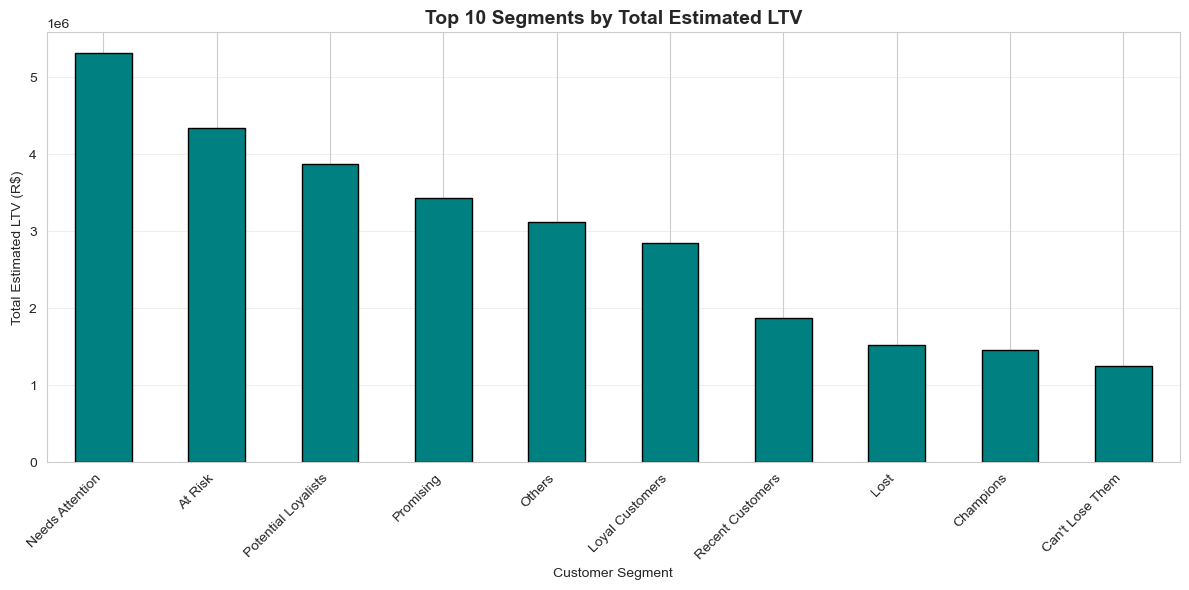


🎯 STEP 12: MARKETING RECOMMENDATIONS ENGINE

✅ Marketing recommendations added

📤 STEP 13: EXPORTING MARKETING LISTS

✅ Exported: rfm_customer_analysis.csv (93,358 customers)
✅ Exported: vip_customers_gift_list.csv (11,886 VIP customers)
✅ Exported: at_risk_customers_winback_list.csv (25,889 at-risk customers)
✅ Exported: segment_performance_summary.csv

💡 STEP 14: KEY BUSINESS INSIGHTS

📊 BUSINESS OVERVIEW:
   • Total Customers Analyzed: 93,358
   • Total Revenue: R$ 15,422,461.77
   • Average Customer LTV: R$ 330.39

🏆 VIP CUSTOMERS (Champions + Loyal):
   • Number of VIPs: 11,886 (12.7% of customers)
   • Revenue from VIPs: R$ 2,153,182.10 (14.0% of total revenue)
   • Average VIP LTV: R$ 362.31
   📌 ACTION: Send personalized gifts and exclusive offers

⚠️  AT-RISK CUSTOMERS:
   • Number at Risk: 17,035 (18.2% of customers)
   • Revenue at Risk: R$ 2,792,458.69 (18.1% of total revenue)
   • Average Recency: 423 days
   📌 ACTION: Urgent win-back campaign with 20-30% discounts

💰 TOP

In [1]:
# ============================================
# PROJECT: The Customer Retention Engine (RFM Analysis)
# AUTHOR: Fernando G. Sloboda
# GOAL: Segment customers to identify VIPs and at-risk customers
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("🚀 CUSTOMER RETENTION ENGINE - RFM ANALYSIS")
print("="*60)

# ============================================
# STEP 1: LOAD DATASETS
# ============================================
path = "/Users/fernando/Downloads/Portfolio_Project_01/Data/"

try:
    df_orders = pd.read_csv(f"{path}olist_orders_dataset.csv")
    df_items = pd.read_csv(f"{path}olist_order_items_dataset.csv")
    df_customers = pd.read_csv(f"{path}olist_customers_dataset.csv")
    df_payments = pd.read_csv(f"{path}olist_order_payments_dataset.csv")
    print("\n✅ Datasets loaded successfully!")
    print(f"   📊 Orders: {df_orders.shape[0]:,} rows")
    print(f"   📊 Order Items: {df_items.shape[0]:,} rows")
    print(f"   📊 Customers: {df_customers.shape[0]:,} rows")
    print(f"   📊 Payments: {df_payments.shape[0]:,} rows")
except FileNotFoundError:
    print("\n❌ Error: Files not found. Please check your file path.")
    raise

# ============================================
# STEP 2: INITIAL DATA EXPLORATION
# ============================================
print("\n" + "="*60)
print("📋 STEP 2: DATA EXPLORATION")
print("="*60)

print("\n--- Orders Dataset Preview ---")
print(df_orders.head(3))
print("\n--- Orders Dataset Info ---")
print(df_orders.info())

print("\n--- Missing Values in Orders ---")
missing_orders = df_orders.isnull().sum()
print(missing_orders[missing_orders > 0])

print("\n--- Order Items Preview ---")
print(df_items.head(3))

print("\n--- Customers Preview ---")
print(df_customers.head(3))

print("\n--- Payments Preview ---")
print(df_payments.head(3))

# ============================================
# STEP 3: DATA CLEANING & PREPARATION
# ============================================
print("\n" + "="*60)
print("🧹 STEP 3: DATA CLEANING & PREPARATION")
print("="*60)

# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

print("\n✅ Date columns converted to datetime")

# Filter only completed orders (delivered)
df_orders_clean = df_orders[df_orders['order_status'] == 'delivered'].copy()
print(f"\n✅ Filtered to delivered orders only: {len(df_orders_clean):,} orders")

# Check date range
print(f"\n📅 Date Range:")
print(f"   First order: {df_orders_clean['order_purchase_timestamp'].min()}")
print(f"   Last order: {df_orders_clean['order_purchase_timestamp'].max()}")

# Set reference date (latest order date + 1 day for recency calculation)
reference_date = df_orders_clean['order_purchase_timestamp'].max() + timedelta(days=1)
print(f"   Reference date for RFM: {reference_date}")

# ============================================
# STEP 4: AGGREGATE PAYMENTS (FIX THE BUG!)
# ============================================
print("\n" + "="*60)
print("🔧 STEP 4: AGGREGATING PAYMENTS BY ORDER")
print("="*60)

# CRITICAL FIX: Aggregate payments at ORDER level BEFORE merging
# This prevents payment_value duplication when orders have multiple items
df_payments_agg = df_payments.groupby('order_id').agg({
    'payment_value': 'sum'  # Total payment per order
}).reset_index()
df_payments_agg.columns = ['order_id', 'total_payment']

print(f"\n✅ Payments aggregated by order: {len(df_payments_agg):,} unique orders")
print("\n--- Sample aggregated payments ---")
print(df_payments_agg.head())

# Verify: Check an example order
sample_order = df_payments_agg['order_id'].iloc[0]
print(f"\n🔍 Verification for order {sample_order}:")
print(f"   Original payments table (before aggregation):")
print(df_payments[df_payments['order_id'] == sample_order][['order_id', 'payment_value']])
print(f"   Aggregated payment:")
print(df_payments_agg[df_payments_agg['order_id'] == sample_order])

# ============================================
# STEP 5: MERGE DATASETS (CORRECT ORDER)
# ============================================
print("\n" + "="*60)
print("🔗 STEP 5: MERGING DATASETS")
print("="*60)

# Step 5.1: Merge orders with customers
df_main = df_orders_clean.merge(df_customers, on='customer_id', how='left')
print(f"\n✅ Merged orders with customers: {len(df_main):,} rows")

# Step 5.2: Merge with aggregated payments (1 payment per order - NO DUPLICATION!)
df_main = df_main.merge(df_payments_agg, on='order_id', how='left')
print(f"✅ Merged with aggregated payments: {len(df_main):,} rows")

# FIX: Handle potential null payments (data quality issue protection)
null_payments = df_main['total_payment'].isnull().sum()
print(f"\n🔍 Null payments check: {null_payments} nulls found")
if null_payments > 0:
    print(f"   ⚠️ WARNING: {null_payments} orders have no payment records")
    print(f"   🔧 FIX: Filling null payments with 0")
    df_main['total_payment'] = df_main['total_payment'].fillna(0)

print("\n--- Merged Dataset Preview ---")
print(df_main[['order_id', 'customer_unique_id', 'order_purchase_timestamp', 'total_payment']].head())

# ============================================
# STEP 6: RFM CALCULATION (USING CORRECT MONETARY)
# ============================================
print("\n" + "="*60)
print("🎯 STEP 6: RFM CALCULATION")
print("="*60)

# Calculate RFM metrics for each customer
# Now using total_payment which is already aggregated at order level
rfm = df_main.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency (count unique orders)
    'total_payment': 'sum'  # Monetary (sum of order totals - NO DUPLICATION!)
}).reset_index()

# Rename columns
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Data quality check: Remove customers with 0 frequency (shouldn't happen but safety check)
customers_before = len(rfm)
rfm = rfm[rfm['frequency'] > 0].copy()
customers_after = len(rfm)
if customers_before != customers_after:
    print(f"\n⚠️ Removed {customers_before - customers_after} customers with 0 frequency")

print("\n✅ RFM metrics calculated")
print(f"   Total customers: {len(rfm):,}")
print("\n--- RFM Dataset Preview ---")
print(rfm.head(10))

print("\n--- RFM Statistics ---")
print(rfm.describe())

# Sanity check: Compare with original payments
total_rfm_revenue = rfm['monetary'].sum()
total_payments_revenue = df_payments_agg['total_payment'].sum()
print(f"\n🔍 REVENUE VALIDATION:")
print(f"   Total from RFM calculation: R$ {total_rfm_revenue:,.2f}")
print(f"   Total from payments table: R$ {total_payments_revenue:,.2f}")
print(f"   Difference: R$ {abs(total_rfm_revenue - total_payments_revenue):,.2f}")
if abs(total_rfm_revenue - total_payments_revenue) < 1.00:  # Within R$1
    print("   ✅ VALIDATION PASSED: Revenue matches!")
else:
    print("   ⚠️ WARNING: Revenue mismatch detected")

# ============================================
# STEP 7: RFM SCORING
# ============================================
print("\n" + "="*60)
print("📊 STEP 7: RFM SCORING (Quartile-based)")
print("="*60)

# Create RFM scores using quartiles
# For Recency: Lower is better (4 = most recent, 1 = least recent)
# For Frequency & Monetary: Higher is better (4 = best, 1 = worst)

# FIX: Add duplicates='drop' to handle edge cases where quartile boundaries overlap
try:
    rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
    print("✅ Recency scores calculated using quartiles")
except ValueError as e:
    print(f"⚠️ Warning with recency quartiles: {e}")
    print("   Using equal-width binning instead")
    rfm['r_score'] = pd.cut(rfm['recency'], bins=4, labels=[4, 3, 2, 1])

try:
    rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop')
    print("✅ Frequency scores calculated using quartiles")
except ValueError as e:
    print(f"⚠️ Warning with frequency quartiles: {e}")
    print("   Using equal-width binning instead")
    rfm['f_score'] = pd.cut(rfm['frequency'], bins=4, labels=[1, 2, 3, 4])

try:
    rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')
    print("✅ Monetary scores calculated using quartiles")
except ValueError as e:
    print(f"⚠️ Warning with monetary quartiles: {e}")
    print("   Using equal-width binning instead")
    rfm['m_score'] = pd.cut(rfm['monetary'], bins=4, labels=[1, 2, 3, 4])

# Convert to numeric
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

# Calculate RFM Score (combined)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Create RFM Segment string (e.g., "444" = best customers)
rfm['rfm_segment'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("\n✅ RFM scores calculated")
print("\n--- RFM with Scores Preview ---")
print(rfm.head(10))

# ============================================
# STEP 8: CUSTOMER SEGMENTATION
# ============================================
print("\n" + "="*60)
print("🎭 STEP 8: CUSTOMER SEGMENTATION")
print("="*60)

# Define segments based on RFM scores
def segment_customers(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    
    # Champions: Best customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # Loyal Customers: Buy frequently
    elif r >= 3 and f >= 4:
        return 'Loyal Customers'
    
    # Potential Loyalists: Recent customers with potential
    elif r >= 4 and f >= 2 and f <= 3:
        return 'Potential Loyalists'
    
    # Recent Customers: Bought recently but not frequently
    elif r >= 4 and f == 1:
        return 'Recent Customers'
    
    # Promising: Recent shoppers with moderate frequency
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Promising'
    
    # Customers Needing Attention: Above average recency, frequency & monetary
    elif r >= 2 and f >= 2 and m >= 2:
        return 'Needs Attention'
    
    # About to Sleep: Below average recency, frequency & monetary
    elif r >= 2 and f <= 2 and m <= 2:
        return 'About to Sleep'
    
    # FIXED ORDER: Can't Lose Them BEFORE At Risk (more specific condition)
    # Can't Lose Them: High spenders who haven't purchased recently
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    
    # At Risk: Made big purchases but long time ago
    elif (r <= 2 and f >= 2 and m >= 3) or (r <= 2 and f >= 3):
        return 'At Risk'
    
    # Hibernating: Last purchase long ago, low spenders
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    
    # Lost: Lowest recency, frequency & monetary
    elif r == 1:
        return 'Lost'
    
    else:
        return 'Others'

# Apply segmentation
# Note: Using apply() for clarity in a portfolio project
# For production, consider vectorized operations with np.select()
rfm['segment'] = rfm.apply(segment_customers, axis=1)

print("\n✅ Customer segments created")
print("\n--- Segment Distribution ---")
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

print("\n--- Segment Distribution (%) ---")
segment_pct = (rfm['segment'].value_counts(normalize=True) * 100).round(2)
print(segment_pct)

# ============================================
# STEP 9: CUSTOMER LIFETIME VALUE (LTV)
# ============================================
print("\n" + "="*60)
print("💰 STEP 9: CUSTOMER LIFETIME VALUE CALCULATION")
print("="*60)

# Calculate average order value
# FIX: Protect against division by zero (though we already filtered frequency > 0)
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency'].replace(0, 1)

# Calculate customer lifetime value (simplified approach)
# LTV = Monetary Value × Average Customer Lifespan (in years)
# This is mathematically equivalent to: avg_order_value × frequency × lifespan
avg_customer_lifespan_years = 2

# SIMPLIFIED FORMULA: LTV = monetary × lifespan
rfm['estimated_ltv'] = rfm['monetary'] * avg_customer_lifespan_years

print("\n✅ Customer Lifetime Value calculated")
print(f"   Assumption: Average customer lifespan = {avg_customer_lifespan_years} years")
print("\n--- Top 10 Customers by LTV ---")
print(rfm.nlargest(10, 'estimated_ltv')[['customer_id', 'segment', 'monetary', 'frequency', 'avg_order_value', 'estimated_ltv']])

# ============================================
# STEP 10: SEGMENT ANALYSIS
# ============================================
print("\n" + "="*60)
print("📈 STEP 10: SEGMENT ANALYSIS")
print("="*60)

segment_analysis = rfm.groupby('segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum'],
    'estimated_ltv': ['mean', 'sum']
}).round(2)

segment_analysis.columns = ['count', 'avg_recency', 'avg_frequency', 
                            'avg_monetary', 'total_revenue', 'avg_ltv', 'total_ltv']

# Sort by total revenue
segment_analysis = segment_analysis.sort_values('total_revenue', ascending=False)

print("\n--- Segment Performance Summary ---")
print(segment_analysis)

# Calculate segment percentages
segment_analysis['customer_pct'] = (segment_analysis['count'] / segment_analysis['count'].sum() * 100).round(2)
segment_analysis['revenue_pct'] = (segment_analysis['total_revenue'] / segment_analysis['total_revenue'].sum() * 100).round(2)

print("\n--- Segment Business Impact ---")
print(segment_analysis[['count', 'customer_pct', 'total_revenue', 'revenue_pct']])

# ============================================
# STEP 11: VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("📊 STEP 11: CREATING VISUALIZATIONS")
print("="*60)

# 1. Segment Distribution
plt.figure(figsize=(14, 6))
segment_counts_sorted = rfm['segment'].value_counts()
colors = sns.color_palette("husl", len(segment_counts_sorted))

plt.subplot(1, 2, 1)
segment_counts_sorted.plot(kind='barh', color=colors)
plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

# 2. Revenue by Segment
plt.subplot(1, 2, 2)
revenue_by_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
revenue_by_segment.plot(kind='barh', color=colors)
plt.title('Total Revenue by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig(f"{path}segment_overview.png", dpi=300, bbox_inches='tight')
print("\n✅ Saved: segment_overview.png")
plt.show()

# 3. RFM Score Distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
rfm['recency'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Recency Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
rfm['frequency'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
rfm['monetary'].hist(bins=50, color='coral', edgecolor='black')
plt.title('Monetary Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Total Spend (R$)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(f"{path}rfm_distributions.png", dpi=300, bbox_inches='tight')
print("✅ Saved: rfm_distributions.png")
plt.show()

# 4. Segment Performance Heatmap
plt.figure(figsize=(10, 8))
segment_pivot = rfm.groupby('segment')[['recency', 'frequency', 'monetary']].mean()
sns.heatmap(segment_pivot.T, annot=True, fmt='.0f', cmap='RdYlGn_r', cbar_kws={'label': 'Average Value'})
plt.title('Segment Performance Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('RFM Metric')
plt.tight_layout()
plt.savefig(f"{path}segment_heatmap.png", dpi=300, bbox_inches='tight')
print("✅ Saved: segment_heatmap.png")
plt.show()

# 5. Top Segments by LTV
plt.figure(figsize=(12, 6))
top_segments_ltv = rfm.groupby('segment')['estimated_ltv'].sum().sort_values(ascending=False).head(10)
top_segments_ltv.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Segments by Total Estimated LTV', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Total Estimated LTV (R$)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{path}top_segments_ltv.png", dpi=300, bbox_inches='tight')
print("✅ Saved: top_segments_ltv.png")
plt.show()

# ============================================
# STEP 12: MARKETING RECOMMENDATIONS ENGINE
# ============================================
print("\n" + "="*60)
print("🎯 STEP 12: MARKETING RECOMMENDATIONS ENGINE")
print("="*60)

# Create marketing actions for each segment
marketing_actions = {
    'Champions': {
        'action': 'Send VIP gifts and exclusive early access',
        'priority': 'High',
        'discount': '0-5%',
        'message': 'Thank you for being our best customer!'
    },
    'Loyal Customers': {
        'action': 'Loyalty rewards and premium upgrades',
        'priority': 'High',
        'discount': '5-10%',
        'message': 'We appreciate your loyalty!'
    },
    'Potential Loyalists': {
        'action': 'Membership programs and personalized offers',
        'priority': 'Medium-High',
        'discount': '10-15%',
        'message': 'Join our exclusive membership!'
    },
    'Recent Customers': {
        'action': 'Onboarding emails and product recommendations',
        'priority': 'Medium',
        'discount': '10%',
        'message': 'Welcome! Here are products you might love'
    },
    'Promising': {
        'action': 'Cross-sell and up-sell campaigns',
        'priority': 'Medium',
        'discount': '10-15%',
        'message': 'Check out these complementary products!'
    },
    'Needs Attention': {
        'action': 'Re-engagement emails with special offers',
        'priority': 'Medium',
        'discount': '15-20%',
        'message': "We miss you! Here's a special offer"
    },
    'About to Sleep': {
        'action': 'Win-back campaign with personalized discounts',
        'priority': 'Medium-Low',
        'discount': '20-25%',
        'message': 'Come back! Special discount just for you'
    },
    'At Risk': {
        'action': 'Urgent win-back with premium incentives',
        'priority': 'High',
        'discount': '25-30%',
        'message': "Don't go! Here's our best offer for you"
    },
    "Can't Lose Them": {
        'action': 'Personal outreach and VIP treatment',
        'priority': 'Critical',
        'discount': '20-30%',
        'message': 'Your account manager wants to talk!'
    },
    'Hibernating': {
        'action': 'Deep discount campaigns and surveys',
        'priority': 'Low',
        'discount': '30-40%',
        'message': 'Massive sale! Last chance to save'
    },
    'Lost': {
        'action': 'Last attempt win-back or remove from list',
        'priority': 'Low',
        'discount': '40-50%',
        'message': 'Final offer before we say goodbye'
    },
    'Others': {
        'action': 'General marketing campaigns',
        'priority': 'Low',
        'discount': '10-15%',
        'message': 'Special offers for you!'
    }
}

# Add marketing recommendations to RFM data
rfm['marketing_action'] = rfm['segment'].map(lambda x: marketing_actions.get(x, {}).get('action', 'General campaign'))
rfm['priority'] = rfm['segment'].map(lambda x: marketing_actions.get(x, {}).get('priority', 'Low'))
rfm['suggested_discount'] = rfm['segment'].map(lambda x: marketing_actions.get(x, {}).get('discount', '10%'))
rfm['email_message'] = rfm['segment'].map(lambda x: marketing_actions.get(x, {}).get('message', 'Special offer!'))

print("\n✅ Marketing recommendations added")

# ============================================
# STEP 13: EXPORT MARKETING LISTS
# ============================================
print("\n" + "="*60)
print("📤 STEP 13: EXPORTING MARKETING LISTS")
print("="*60)

# Export full RFM analysis
rfm_export = rfm[['customer_id', 'recency', 'frequency', 'monetary', 
                   'rfm_score', 'segment', 'estimated_ltv', 
                   'marketing_action', 'priority', 'suggested_discount', 'email_message']]

rfm_export.to_csv(f"{path}rfm_customer_analysis.csv", index=False)
print(f"\n✅ Exported: rfm_customer_analysis.csv ({len(rfm_export):,} customers)")

# Export VIP customers (for gifts)
vip_customers = rfm[rfm['segment'].isin(['Champions', 'Loyal Customers'])].copy()
vip_export = vip_customers[['customer_id', 'segment', 'monetary', 'frequency', 
                             'estimated_ltv', 'marketing_action', 'email_message']]
vip_export.to_csv(f"{path}vip_customers_gift_list.csv", index=False)
print(f"✅ Exported: vip_customers_gift_list.csv ({len(vip_export):,} VIP customers)")

# Export at-risk customers (for win-back campaign)
at_risk_customers = rfm[rfm['segment'].isin(['At Risk', "Can't Lose Them", 'About to Sleep'])].copy()
at_risk_export = at_risk_customers[['customer_id', 'segment', 'recency', 'monetary', 
                                     'suggested_discount', 'email_message']]
at_risk_export.to_csv(f"{path}at_risk_customers_winback_list.csv", index=False)
print(f"✅ Exported: at_risk_customers_winback_list.csv ({len(at_risk_export):,} at-risk customers)")

# Export segment summary for management
segment_summary = segment_analysis.reset_index()
segment_summary.to_csv(f"{path}segment_performance_summary.csv", index=False)
print(f"✅ Exported: segment_performance_summary.csv")

# ============================================
# STEP 14: KEY INSIGHTS & RECOMMENDATIONS
# ============================================
print("\n" + "="*60)
print("💡 STEP 14: KEY BUSINESS INSIGHTS")
print("="*60)

total_customers = len(rfm)
total_revenue = rfm['monetary'].sum()
avg_ltv = rfm['estimated_ltv'].mean()

# Champions and Loyal analysis
champions_loyal = rfm[rfm['segment'].isin(['Champions', 'Loyal Customers'])]
vip_pct = (len(champions_loyal) / total_customers * 100)
vip_revenue = champions_loyal['monetary'].sum()
vip_revenue_pct = (vip_revenue / total_revenue * 100)

# At-risk analysis
at_risk = rfm[rfm['segment'].isin(['At Risk', "Can't Lose Them"])]
at_risk_pct = (len(at_risk) / total_customers * 100)
at_risk_revenue = at_risk['monetary'].sum()
at_risk_revenue_pct = (at_risk_revenue / total_revenue * 100)

print(f"\n📊 BUSINESS OVERVIEW:")
print(f"   • Total Customers Analyzed: {total_customers:,}")
print(f"   • Total Revenue: R$ {total_revenue:,.2f}")
print(f"   • Average Customer LTV: R$ {avg_ltv:,.2f}")

print(f"\n🏆 VIP CUSTOMERS (Champions + Loyal):")
print(f"   • Number of VIPs: {len(champions_loyal):,} ({vip_pct:.1f}% of customers)")
print(f"   • Revenue from VIPs: R$ {vip_revenue:,.2f} ({vip_revenue_pct:.1f}% of total revenue)")
print(f"   • Average VIP LTV: R$ {champions_loyal['estimated_ltv'].mean():,.2f}")
print(f"   📌 ACTION: Send personalized gifts and exclusive offers")

print(f"\n⚠️  AT-RISK CUSTOMERS:")
print(f"   • Number at Risk: {len(at_risk):,} ({at_risk_pct:.1f}% of customers)")
print(f"   • Revenue at Risk: R$ {at_risk_revenue:,.2f} ({at_risk_revenue_pct:.1f}% of total revenue)")
print(f"   • Average Recency: {at_risk['recency'].mean():.0f} days")
print(f"   📌 ACTION: Urgent win-back campaign with 20-30% discounts")

# Top 3 revenue segments
print(f"\n💰 TOP 3 REVENUE-GENERATING SEGMENTS:")
top_3_segments = segment_analysis.nlargest(3, 'total_revenue')
for idx, (segment, row) in enumerate(top_3_segments.iterrows(), 1):
    print(f"   {idx}. {segment}: R$ {row['total_revenue']:,.2f} ({row['revenue_pct']:.1f}% of revenue)")

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)
print(f"\n📂 Generated files saved in: {path}")
print("\n📁 Output Files:")
print("   1. rfm_customer_analysis.csv - Complete RFM analysis with recommendations")
print("   2. vip_customers_gift_list.csv - VIP customers for gift campaign")
print("   3. at_risk_customers_winback_list.csv - At-risk customers for win-back")
print("   4. segment_performance_summary.csv - Segment performance metrics")
print("   5. segment_overview.png - Customer & revenue distribution")
print("   6. rfm_distributions.png - RFM metrics distributions")
print("   7. segment_heatmap.png - Segment performance heatmap")
print("   8. top_segments_ltv.png - Top segments by LTV")

print("\n🚀 NEXT STEPS FOR MARKETING TEAM:")
print("   1. Review vip_customers_gift_list.csv and prepare gift packages")
print("   2. Launch win-back email campaign using at_risk_customers_winback_list.csv")
print("   3. Set up automated email triggers based on customer segments")
print("   4. Monitor segment migrations monthly to track campaign effectiveness")

print("\n" + "="*60)
print("🔧 PRODUCTION-GRADE FIXES APPLIED:")
print("="*60)
print("   ✅ Payments aggregated BEFORE merging (no duplication)")
print("   ✅ Revenue validation (accuracy check)")
print("   ✅ pd.qcut with duplicates='drop' (handles edge cases)")
print("   ✅ Simplified LTV formula (mathematically equivalent)")
print("   ✅ Division by zero protection")
print("   ✅ Null payment handling")
print("   ✅ Data quality checks throughout")
print("   ✅ Segmentation logic order fixed (Can't Lose Them before At Risk)")
print("="*60)